# LandArchetypes β€” Demo Workflow
**Study area:** Thrace, Greece  
**Stage:** 1 β€” Land Archetype classification (mandatory)  

This notebook demonstrates the end-to-end workflow:
1. Clip input rasters to the study area boundary
2. Create coastline and river proximity buffer rasters
3. Align all rasters to a common grid (EPSG:3035, 100 m)
4. Classify the landscape into 15 land archetype classes
5. Visualise the archetype map
6. Profile the study area (hazard layers, community systems, area statistics)

> **Run this notebook from the project root directory** so that relative paths resolve correctly.

In [15]:
import json
from pathlib import Path
from importlib.resources import files

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import rioxarray as rxr
import geopandas as gpd

from land_archetypes import (
    ArchetypeClassification,
    ArchetypeProfiler,
    GeospatialProcessingUtilities,
)
from land_archetypes.input_layers_mapping.mapping_tools import (
    build_eunis_code_map,
    build_clc_code_map,
)

In [16]:
# All paths are relative to the project root.
BASE_DIR   = Path(".").resolve()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent
INPUT_DIR  = BASE_DIR / "input_data"
OUTPUT_DIR = BASE_DIR / "output_data"
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Input rasters ---
CLC_PATH   = INPUT_DIR / "corine"                   / "U2018_CLC2018_V2020_20u1.tif"
EUNIS_PATH = INPUT_DIR / "eunis"                    / "eea_r_3035_100_m_etm-full_2012_v3-1_r00.tif"
IMP_PATH   = INPUT_DIR / "copernicus_imperviousness" / "copernicus_imperviousness.tif"
DEM_PATH   = INPUT_DIR / "dem.tif"
POP_PATH   = INPUT_DIR / "grc_T_T_2021_CN_100m_R2025A_v1.tif"

# --- Input vectors ---
LINES_GPKG        = INPUT_DIR / "coastline_and_rivers.gpkg"
STUDY_AREA_GPKG   = INPUT_DIR / "remth.gpkg"
STUDY_AREA_LAYER  = "thrace_fixed_coastlines"

# --- Clipped raster output names (relative to OUTPUT_DIR) ---
CLC_CLIP   = OUTPUT_DIR / "clc_clipped.tif"
EUNIS_CLIP = OUTPUT_DIR / "eunis_clipped.tif"
IMP_CLIP   = OUTPUT_DIR / "imperviousness_clipped.tif"
DEM_CLIP   = OUTPUT_DIR / "dem_clipped.tif"
POP_CLIP   = OUTPUT_DIR / "pop_density_clipped.tif"
COAST_BUF  = OUTPUT_DIR / "coast_buffer.tif"
RIVER_BUF  = OUTPUT_DIR / "river_buffer.tif"

# --- Buffer distances (metres) ---
COAST_BUFFER_DIST = 1000   # adjust as needed
RIVER_BUFFER_DIST = 300   # adjust as needed

print(f"Project root : {BASE_DIR}")
print(f"Output folder: {OUTPUT_DIR}")



Project root : C:\Users\xylop\Documents\github_repos\archetype_mapper
Output folder: C:\Users\xylop\Documents\github_repos\archetype_mapper\output_data


In [17]:
geo = GeospatialProcessingUtilities(
    output_path=str(OUTPUT_DIR),
    study_area_path=str(STUDY_AREA_GPKG),
    study_area_layer=STUDY_AREA_LAYER,
)

rasters_to_clip = {
    "clc_clipped.tif":              str(CLC_PATH),
    "eunis_clipped.tif":            str(EUNIS_PATH),
    "imperviousness_clipped.tif":   str(IMP_PATH),
    "dem_clipped.tif":              str(DEM_PATH),
    "pop_density_clipped.tif":      str(POP_PATH),
}

---
## Step 1 β€” Clip input rasters to the study area

In [ ]:
for output_name, raster_path in rasters_to_clip.items():
    print(f"  Clipping {Path(raster_path).name} ...")
    geo.clip_raster_by_vector(output_name, raster_path)

print("\nAll rasters clipped.")

  Clipping U2018_CLC2018_V2020_20u1.tif ...
  Clipping eea_r_3035_100_m_etm-full_2012_v3-1_r00.tif ...
  Clipping copernicus_imperviousness.tif ...
  Clipping dem.tif ...
  Clipping grc_T_T_2021_CN_100m_R2025A_v1.tif ...

All rasters clipped.


---
## Step 2 β€” Create coastline and river buffer rasters

The clipped CLC raster is used as the spatial reference so the buffers are
produced on the same grid (EPSG:3035, 100 m).  
Buffer distances are set in the configuration cell above.

In [11]:
print(f"Creating coastline buffer ({COAST_BUFFER_DIST} m) ...")
geo.create_line_buffer_raster(
    "coast_buffer.tif",
    line_path=str(LINES_GPKG),
    buffer_distance=COAST_BUFFER_DIST,
    line_layer="coastline",
    reference_raster_path=str(CLC_CLIP),
)

print(f"Creating river buffer ({RIVER_BUFFER_DIST} m) ...")
geo.create_line_buffer_raster(
    "river_buffer.tif",
    line_path=str(LINES_GPKG),
    buffer_distance=RIVER_BUFFER_DIST,
    line_layer="rivers",
    reference_raster_path=str(CLC_CLIP),
)

print("Buffer rasters created.")

Creating coastline buffer (1000 m) ...
Creating river buffer (300 m) ...
Buffer rasters created.


---
## Step 3 β€” Load and align all rasters to a common grid

All rasters are reprojected to **EPSG:3035** at **100 m** resolution and
matched to the CLC grid using `reproject_match`.  
Categorical layers (CLC, EUNIS, buffers) use nearest-neighbour resampling;
continuous layers (DEM, imperviousness, population density) use bilinear.

In [18]:
print("Loading clipped rasters ...")

raw = {
    "clc":                rxr.open_rasterio(CLC_CLIP,   masked=True, chunks="auto"),
    "eunis":              rxr.open_rasterio(EUNIS_CLIP,  masked=True, chunks="auto"),
    "imperviousness":     rxr.open_rasterio(IMP_CLIP,   masked=True, chunks="auto"),
    "dem":                rxr.open_rasterio(DEM_CLIP,    masked=True, chunks="auto"),
    "population_density": rxr.open_rasterio(POP_CLIP,   masked=True, chunks="auto"),
    "coast_buffer":       rxr.open_rasterio(COAST_BUF,  masked=True, chunks="auto"),
    "river_buffer":       rxr.open_rasterio(RIVER_BUF,  masked=True, chunks="auto"),
}

print(f"{'Layer':<22} {'Shape':>16}  CRS")
print("-" * 60)
for name, da in raw.items():
    shape = str(tuple(da.squeeze().shape))
    print(f"{name:<22} {shape:>16}  {da.rio.crs}")

Loading clipped rasters ...
Layer                             Shape  CRS
------------------------------------------------------------
clc                        (1592, 2473)  EPSG:3035
eunis                      (1592, 2473)  EPSG:3035
imperviousness           (15908, 24722)  EPSG:3035
dem                        (5304, 8241)  EPSG:3035
population_density         (1988, 3089)  EPSG:3035
coast_buffer               (1592, 2473)  EPSG:3035
river_buffer               (1592, 2473)  EPSG:3035


In [19]:
print("Reprojecting and aligning to CLC grid (EPSG:3035, 100 m) ...")

ras = geo.reproject_rasters(
    raw,
    target_crs=3035,
    reference_key="clc",
    pixel_size=100,
    categorical_keys={"clc", "eunis", "coast_buffer", "river_buffer"},
)

print(f"\n{'Layer':<22} {'Shape':>16}  CRS")
print("-" * 60)
for name, da in ras.items():
    shape = str(tuple(da.squeeze().shape))
    print(f"{name:<22} {shape:>16}  {da.rio.crs}")

print("\nAll rasters aligned.")

Reprojecting and aligning to CLC grid (EPSG:3035, 100 m) ...

Layer                             Shape  CRS
------------------------------------------------------------
clc                        (1592, 2473)  EPSG:3035
eunis                      (1592, 2473)  EPSG:3035
imperviousness             (1592, 2473)  EPSG:3035
dem                        (1592, 2473)  EPSG:3035
population_density         (1592, 2473)  EPSG:3035
coast_buffer               (1592, 2473)  EPSG:3035
river_buffer               (1592, 2473)  EPSG:3035

All rasters aligned.


---
## Step 4 β€” Build code maps and load archetype rules

In [20]:
# Load mapping tables from the installed package data
eunis_df = pd.read_csv(files("land_archetypes") / "input_layers_mapping" / "eunis_l2_mapping.csv")
clc_df   = pd.read_csv(files("land_archetypes") / "input_layers_mapping" / "clc_mapping.csv")

eunis_map = build_eunis_code_map(eunis_df)
clc_map   = build_clc_code_map(clc_df)

print(f"EUNIS code map : {len(eunis_map)} entries")
print(f"CLC code map   : {len(clc_map)} entries")

# Load archetype rules from local source (picks up any edits without reinstalling)
_rules_path = BASE_DIR / "src" / "land_archetypes" / "archetype_classes" / "archetype_classes.json"
with open(_rules_path, "r", encoding="utf-8") as f:
    rules = json.load(f)

print(f"Archetype rules: {len(rules)} archetypes")
print(f"Rules loaded from: {_rules_path}")

EUNIS code map : 44 entries
CLC code map   : 45 entries
Archetype rules: 15 archetypes
Rules loaded from: C:\Users\xylop\Documents\github_repos\archetype_mapper\src\land_archetypes\archetype_classes\archetype_classes.json


---
## Step 5 β€” Land Archetype classification

Classification follows a **first-match-wins** precedence order (most spatially
constrained archetype checked first).  
See `README.md` for the full precedence table and instructions on overriding
default rule thresholds.

In [21]:
clf = ArchetypeClassification()

archetype_raster = clf.derive_archetype_raster_map(
    output_path=str(OUTPUT_DIR),
    archetype_map_name="archetypes.tif",
    ras=ras,
    rules=rules,
    eunis_code_map=eunis_map,
    clc_code_map=clc_map,
    rule_overrides={
        "C1": {"population_density_constraint": [0, 0]},
        "C3": {"population_density_constraint": [0, 0]},
    },
    # clc_fallback=True,  # second pass: reclassify remaining 255 pixels
    #                     # using CLC only (ignores EUNIS conflicts);
    #                     # saves archetypes_clc_fallback.tif alongside archetypes.tif
)

# Parse lookup (may be a string when re-read from disk)
_lkp = archetype_raster.attrs["class_id_lookup"]
if isinstance(_lkp, str):
    _lkp = json.loads(_lkp)
archetype_raster.attrs["class_id_lookup"] = _lkp

# Save lookup so Step 6+ can be run independently
with open(OUTPUT_DIR / "class_id_lookup.json", "w") as f:
    json.dump(_lkp, f)

print("Classification complete.")
print(f"Output : {OUTPUT_DIR / 'archetypes.tif'}")
print(f"Lookup : {OUTPUT_DIR / 'class_id_lookup.json'}")
print()
print("Class ID lookup:")
for code, id_ in sorted(_lkp.items(), key=lambda x: x[1]):
    print(f"  {id_:>2}  {code}  {rules[code]['name']}")

Classification complete.
Output : C:\Users\xylop\Documents\github_repos\archetype_mapper\output_data\archetypes.tif
Lookup : C:\Users\xylop\Documents\github_repos\archetype_mapper\output_data\class_id_lookup.json

Class ID lookup:
   1  A2  Beach-Dune System
   2  A3  Transitional Coastal Water System
   3  A1  Marine/Subtidal
   4  A4  Coastal Natural Plains & Forests
   5  B3  Coastal Urban
   6  B2  Riverine Urban
   7  B1  Inland Urban
   8  B4  Suburban
   9  B5  Mountainous Urban
  10  D1  Mountainous/Forested
  11  D2  High-Altitude Meadows & Scrub
  12  C2  Inland Waterbody Systems
  13  C3  Rural Settlements
  14  C1  Agricultural Land
  15  C4  Inland Natural Plains & Forests


---
## Step 5b — Diagnose unclassified pixels

`ArchetypeProfiler.diagnose_unclassified` walks every unclassified pixel,
finds the first archetype whose CLC codes match, and reports which constraint
blocks classification — together with a concrete suggestion for each issue.

In [22]:
diag = ArchetypeProfiler.diagnose_unclassified(
    archetype_raster=archetype_raster,
    ras=ras,
    rules=rules,
    eunis_code_map=eunis_map,
    clc_code_map=clc_map,
)

print(f"Unclassified pixels : {diag['total_unclassified']:,}  "
      f"({diag['unclassified_pct']:.1f}% of study area)")
print(f"Pixels analysed     : {diag['sample_size']:,}\n")

for arch_key, info in diag["failures"].items():
    print(f"{arch_key}  {info['name']}  —  {info['sampled_count']:,} pixels in sample")
    for r in info["reasons"]:
        print(f"    {r['sampled_count']:>6,}  {r['description']}")
        print(f"           → {r['suggestion']}")
    print()

if diag["no_clc_match"]:
    print("CLC codes not covered by any archetype rule:")
    for entry in diag["no_clc_match"]:
        print(f"    CLC {entry['clc_code']:>4}  ({entry['sampled_count']:,} pixels)")
        print(f"         → {entry['suggestion']}")

Unclassified pixels : 2,694,071  (68.4% of study area)
Pixels analysed     : 50,000

A2  Beach-Dune System  —  52 pixels in sample
        12  EUNIS H2 not in rule
           → Add 'H2' to A2's eunis_codes in archetype_classes.json. Verify that H2 is ecologically consistent with A2.
         9  EUNIS E1 not in rule
           → Add 'E1' to A2's eunis_codes in archetype_classes.json. Verify that E1 is ecologically consistent with A2.
         8  EUNIS C2 not in rule
           → Add 'C2' to A2's eunis_codes in archetype_classes.json. Verify that C2 is ecologically consistent with A2.
         6  EUNIS G1 not in rule
           → Add 'G1' to A2's eunis_codes in archetype_classes.json. Verify that G1 is ecologically consistent with A2.
         5  EUNIS H5 not in rule
           → Add 'H5' to A2's eunis_codes in archetype_classes.json. Verify that H5 is ecologically consistent with A2.
         3  EUNIS D5 not in rule
           → Add 'D5' to A2's eunis_codes in archetype_classes.json. Ve

---
## Step 5c — CLC fallback (optional)

If the diagnostic above shows a significant number of unclassified pixels
caused by CLC / EUNIS mismatches (e.g. agricultural CLC with forest EUNIS),
set `USE_CLC_FALLBACK = True` and re-run this cell.

A second classification pass will run **only on the remaining 255 pixels**,
ignoring the EUNIS constraint and relying on CLC and all other spatial
constraints. Two outputs are saved:

- `archetypes.tif` — first-pass result (CLC + EUNIS)
- `archetypes_clc_fallback.tif` — second-pass result (CLC only for 255 pixels)

Outside-study-area pixels (CLC = NaN) are never affected.

In [23]:
USE_CLC_FALLBACK = True  # set to True after reviewing the Step 5b diagnostics

if USE_CLC_FALLBACK:
    print("Running CLC fallback pass ...")
    archetype_raster = clf.derive_archetype_raster_map(
        output_path=str(OUTPUT_DIR),
        archetype_map_name="archetypes.tif",
        ras=ras,
        rules=rules,
        eunis_code_map=eunis_map,
        clc_code_map=clc_map,
        rule_overrides={
            "C1": {"population_density_constraint": [0, 0]},
            "C3": {"population_density_constraint": [0, 0]},
        },
        clc_fallback=True,
    )
    _lkp = archetype_raster.attrs["class_id_lookup"]
    if isinstance(_lkp, str):
        _lkp = json.loads(_lkp)
    archetype_raster.attrs["class_id_lookup"] = _lkp
    with open(OUTPUT_DIR / "class_id_lookup.json", "w") as f:
        json.dump(_lkp, f)
    print(f"First pass  : {OUTPUT_DIR / 'archetypes.tif'}")
    print(f"CLC fallback: {OUTPUT_DIR / 'archetypes_clc_fallback.tif'}")
else:
    print("CLC fallback skipped. Set USE_CLC_FALLBACK = True to activate.")

Running CLC fallback pass ...


TypeError: ArchetypeClassification.derive_archetype_raster_map() got an unexpected keyword argument 'clc_fallback'

---
## Step 6 β€” Visualise the archetype map

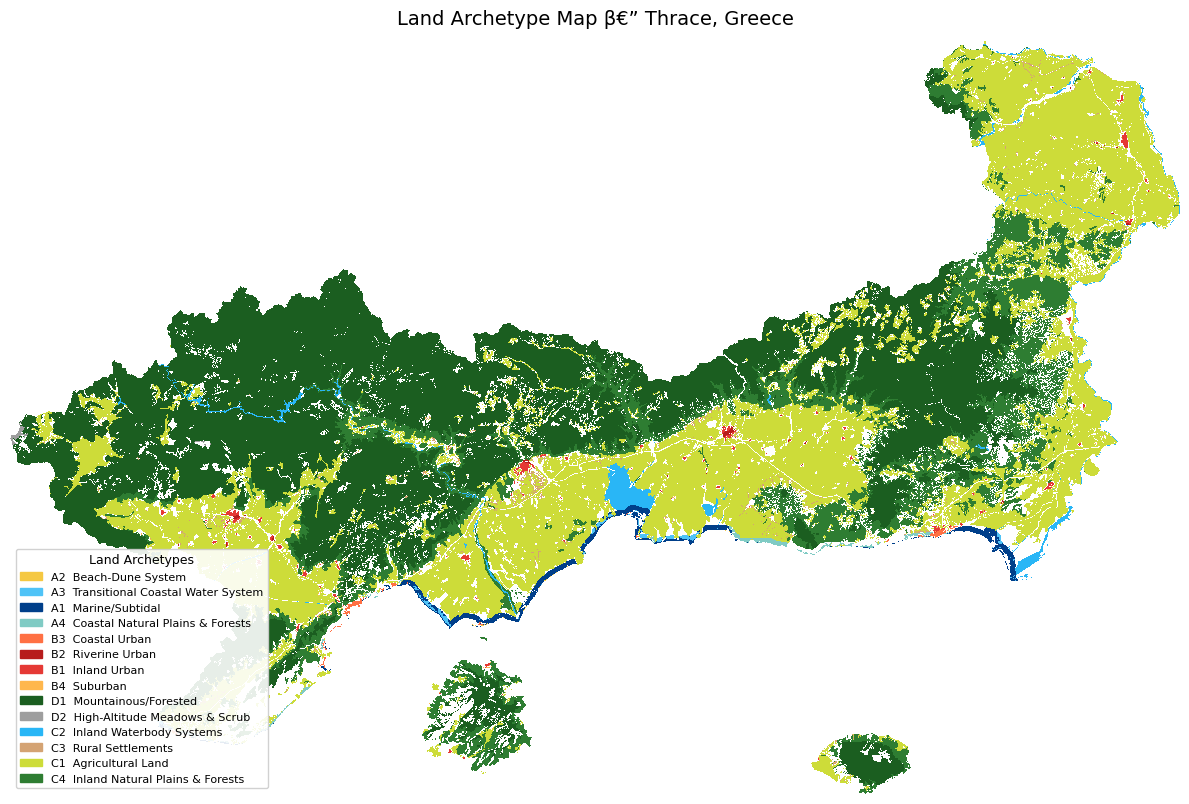

Map saved to C:\Users\xylop\Documents\github_repos\archetype_mapper\output_data\archetype_map.png


In [9]:
try:
    archetype_raster
except NameError:
    _tif = OUTPUT_DIR / "archetypes.tif"
    _lkp = OUTPUT_DIR / "class_id_lookup.json"
    if not _tif.exists():
        raise FileNotFoundError(
            f"No archetype raster found at {_tif}. Run Steps 1–5 first."
        )
    archetype_raster = rxr.open_rasterio(_tif, masked=True).squeeze()
    with open(_lkp) as f:
        archetype_raster.attrs["class_id_lookup"] = json.load(f)
    rules_path = files("land_archetypes") / "archetype_classes" / "archetype_classes.json"
    with rules_path.open("r", encoding="utf-8") as f:
        rules = json.load(f)
    print("Archetype raster loaded from disk.")

# Colour palette β€” one colour per archetype class
ARCHETYPE_COLORS = {
    "A1": "#003f8a",  # Marine/Subtidal
    "A2": "#f5c842",  # Beach-Dune
    "A3": "#4fc3f7",  # Transitional Coastal Water
    "A4": "#80cbc4",  # Coastal Natural Plains & Forests
    "B1": "#e53935",  # Inland Urban
    "B2": "#b71c1c",  # Riverine Urban
    "B3": "#ff7043",  # Coastal Urban
    "B4": "#ffb74d",  # Suburban
    "B5": "#795548",  # Mountainous Urban
    "C1": "#cddc39",  # Agricultural Land
    "C2": "#29b6f6",  # Inland Waterbody Systems
    "C3": "#d4a373",  # Rural Settlements
    "C4": "#2e7d32",  # Inland Natural Plains & Forests
    "D1": "#1b5e20",  # Mountainous/Forested
    "D2": "#9e9e9e",  # High-Altitude Meadows & Scrub
}

lookup = archetype_raster.attrs["class_id_lookup"]
if isinstance(lookup, str):
    lookup = json.loads(lookup)
nodata  = int(archetype_raster.rio.nodata or 255)
arr     = archetype_raster.squeeze().values

# Keep only archetypes actually present in the raster
present_ids  = sorted(set(arr.ravel()) - {nodata})
id_to_key    = {v: k for k, v in lookup.items()}
present_keys = [id_to_key[i] for i in present_ids]

# Map each archetype ID to a sequential plot index
plot_arr = np.full(arr.shape, np.nan)
for idx, arch_id in enumerate(present_ids):
    plot_arr[arr == arch_id] = idx

colors = [ARCHETYPE_COLORS.get(k, "#cccccc") for k in present_keys]
cmap   = mcolors.ListedColormap(colors)
norm   = mcolors.BoundaryNorm(np.arange(-0.5, len(present_ids) + 0.5), cmap.N)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(plot_arr, cmap=cmap, norm=norm, interpolation="none")

legend_patches = [
    mpatches.Patch(
        color=ARCHETYPE_COLORS.get(k, "#cccccc"),
        label=f"{k}  {rules[k]['name']}",
    )
    for k in present_keys
]
ax.legend(
    handles=legend_patches,
    loc="lower left",
    fontsize=8,
    framealpha=0.9,
    title="Land Archetypes",
    title_fontsize=9,
)

ax.set_title("Land Archetype Map β€” Thrace, Greece", fontsize=14, pad=12)
ax.axis("off")
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "archetype_map.png"), dpi=200, bbox_inches="tight")
plt.show()
print(f"Map saved to {OUTPUT_DIR / 'archetype_map.png'}")

---
## Step 7 β€” Study area profile

The `ArchetypeProfiler` surfaces the domain knowledge encoded in the rule set β€”
which hazard layers are needed for this specific study area and which community
systems are at risk β€” without manual inspection of the JSON file.

In [ ]:
profiler = ArchetypeProfiler()
report   = profiler.profile(archetype_raster, rules)

print("=" * 50)
print("Required hazard layers")
print("=" * 50)
for h in report["required_hazard_layers"]:
    print(f"  β€Ά {h}")

print()
print("=" * 50)
print("Community systems at risk (categories)")
print("=" * 50)
for k in report["community_systems_at_risk"]:
    print(f"  β€Ά {k}")

In [ ]:
details = profiler.expand_community_systems(report["community_systems_at_risk"])

print("=" * 50)
print("Key community systems at risk (detailed)")
print("=" * 50)
for category, systems in details.items():
    print(f"\n  {category.upper()}")
    for s in systems:
        print(f"    [{s['id']:2d}]  {s['name']}")

In [ ]:
summary = profiler.area_summary(archetype_raster, rules)

summary.to_csv(OUTPUT_DIR / "area_summary.csv", index=False)
print(f"Area summary saved to {OUTPUT_DIR / 'area_summary.csv'}\n")

summary